# Chapter 4 · Section 4.2
# Nonlinear Least-Squares Problem

**Source:** Li, M.Y. (2018), pp. 111–117.

For models where NO transformation linearizes the parameters (or where you simply want to fit
the original, untransformed model directly), this section develops the **Gauss–Newton method** —
implemented here entirely from scratch and applied to the book's Example 4, then cross-checked
against both the log-linearization shortcut from Sec. 4.1 and `scipy.optimize.curve_fit`.


---
## Block 1 — From SSE to the Gauss–Newton iteration

### 1. Rewrite

For a model $y=f(x,\theta)$ with parameter vector $\theta=(\theta_1,\ldots,\theta_m)$, nonlinear
least squares minimizes $SSE(\theta)=\sum_i[y_i-f(x_i,\theta)]^2$ (4.6). Since $SSE$ is smooth, any
minimum is a critical point: $\partial SSE/\partial\theta_j=0$ for each $j$ (4.7), which by the
chain rule becomes $\sum_i[y_i-f(x_i,\theta)]\cdot\left(-\frac{\partial f}{\partial\theta_j}
(x_i,\theta)\right)=0$ (4.8) — a system that's generally still nonlinear in $\theta$ (since $f$
itself may depend nonlinearly on $\theta$), unlike Sec. 4.1's case. The **Gauss–Newton method**
solves this iteratively: at each current guess $\theta^{(k)}$, Taylor-expand $f$ to *first order*
in $\theta$, substitute into (4.8), and the result becomes a genuinely LINEAR system (in the
*update* $\Delta\theta$) — the **normal system** $J^TJ\Delta\theta=J^T\Delta y$ (4.11), where $J$
is the Jacobian of $f$ with respect to $\theta$ (evaluated at $\theta^{(k)}$) and
$\Delta y_i=y_i-f(x_i,\theta^{(k)})$ are the current residuals. Solving this linear system for
$\Delta\theta$ and updating $\theta^{(k+1)}=\theta^{(k)}+\Delta\theta$, then repeating, is exactly
Newton's method applied to the least-squares problem.

### 2. Explain Like I'm 10

Imagine you're trying to find the lowest point in a hilly, foggy landscape (that's minimizing
$SSE(\theta)$), but you can only see a small patch of ground right around your feet. Gauss–Newton's
strategy: pretend the small patch you can see is perfectly flat-sloped in every direction (that's
the first-order Taylor approximation), figure out exactly where the lowest point of THAT
simplified flat patch would be, walk there, then repeat — look around again from your new spot,
pretend it's flat again, walk to the new lowest point, and so on. Each step is based on an
approximation that's only "locally true," but repeating it enough times, from a reasonable
starting guess, usually walks you all the way down to the real lowest point in the whole
(genuinely hilly, not flat) landscape.

### 3. Key Ideas

- **The chain-rule step (4.7)→(4.8)** is the same "critical point of a smooth function" idea from
  any first calculus course, just applied to a multivariable sum-of-squares function.
- **Linearizing $f$ (not $SSE$ directly)** is the clever trick: Taylor-expanding $f$ to first order
  turns the *nonlinear* normal equations (4.8) into a genuinely *linear* system (4.11) for the
  update step $\Delta\theta$ — reusing Sec. 4.1's entire linear machinery at each iteration.
- **Gauss–Newton reduces exactly to ordinary linear least squares when $f$ is ALREADY linear in
  $\theta$** — Block 2 verifies this consistency check directly.
- **Convergence is only local and not guaranteed** — a poor initial guess $\theta^{(0)}$ can lead
  to slow convergence or failure; this is a genuine practical concern, unlike Sec. 4.1's
  guaranteed-in-one-step linear solve.

### 4. Mathematical Breakdown — verifying Gauss–Newton reduces to linear least squares when $f$ IS linear

If $f(x,\theta)=\alpha(x)\cdot\theta$ (linear in $\theta$), then
$\frac{\partial f}{\partial\theta_j}(x_i,\theta)=\alpha_j(x_i)$ — a CONSTANT (independent of
$\theta$!). So the Jacobian $J$ doesn't actually depend on the current iterate $\theta^{(k)}$ at
all — it's just $J=A=(\alpha_j(x_i))$, the same design matrix from Sec. 4.1. Substituting into the
Gauss–Newton normal system (4.11): $A^TA\Delta\theta=A^T\Delta y$, where
$\Delta y_i=y_i-\alpha(x_i)\cdot\theta^{(k)}=y_i-A\theta^{(k)}$ (evaluated at row $i$). This means
$\theta^{(k+1)}=\theta^{(k)}+\Delta\theta$ solves $A^TA\theta^{(k+1)}=A^TA\theta^{(k)}+A^T(y-A
\theta^{(k)})=A^Ty$ — exactly Sec. 4.1's normal equations, achieved in a SINGLE step regardless of
starting point (since $J$ never changes, the "linearization" is exact, not approximate) — confirming
Gauss–Newton is a strict generalization of ordinary linear least squares, not a different method
that merely resembles it.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $\theta^{(k)}$ | Current parameter estimate at iteration $k$ | Updated each Gauss–Newton step |
| $J=(\partial f_i/\partial\theta_j)$ | Jacobian of the model (NOT of an ODE this time — of the fitting function $f$) | Evaluated at the CURRENT iterate, changes every step (unless $f$ is linear) |
| $\Delta y_i=y_i-f(x_i,\theta^{(k)})$ | Current residuals | The "how far off is the current guess" vector |
| $\Delta\theta$ | The Gauss–Newton update/step | Solves the linear normal system (4.11) at each iteration |


In [1]:
# Symbolic verification: for a LINEAR f, is the Gauss-Newton Jacobian really
# constant (independent of theta), confirming Block 1's derivation?
import sympy as sp

theta0, theta1, x = sp.symbols('theta0 theta1 x')
f_linear = theta0 + theta1 * x   # f(x, theta) = alpha(x) . theta with alpha=(1,x)

J_col0 = sp.diff(f_linear, theta0)
J_col1 = sp.diff(f_linear, theta1)
print("df/d(theta0) =", J_col0, " -- constant (does not depend on theta0, theta1, OR the current iterate)")
print("df/d(theta1) =", J_col1, " -- constant (equals x, again independent of theta)")
print("\nThis confirms: for a linear-in-theta model, the Gauss-Newton Jacobian is exactly")
print("Sec. 4.1's design matrix A, and does not change between iterations.")


df/d(theta0) = 1  -- constant (does not depend on theta0, theta1, OR the current iterate)
df/d(theta1) = x  -- constant (equals x, again independent of theta)

This confirms: for a linear-in-theta model, the Gauss-Newton Jacobian is exactly
Sec. 4.1's design matrix A, and does not change between iterations.


### 10. Verification

Both partial derivatives are confirmed constant (independent of $\theta_0,\theta_1$) — exactly the
condition needed for Gauss–Newton's Jacobian to coincide, unchanged, with Sec. 4.1's design matrix
$A$ at every iteration, confirming the reduction argument in Block 1 symbolically rather than just
algebraically.

---

## Block 2 — Implementing Gauss–Newton from scratch, applied to Example 4

### 1. Rewrite

**Example 4**: fit $x=a_0e^{a_1t}$ to $(1,4.6),(2,8.82),(3,16),(4,31.3),(5,58.5)$. The book solves
this TWO ways: (Solution 1) log-linearize as in Sec. 4.1 Example 3, giving $a_0\approx2.44$,
$a_1\approx0.635$; (Solution 2) apply Gauss–Newton directly to the untransformed model, starting
from $\theta^{(0)}=(1,1)$, converging after 4 iterations to $a_0\approx2.431$, $a_1\approx0.636$ —
agreeing with Solution 1 only to about one decimal place, illustrating that the two methods
genuinely minimize *different* objectives (Solution 1 minimizes squared error in LOG space;
Solution 2 minimizes squared error in the ORIGINAL space) and so need not agree exactly.

### 7. Visual Understanding — implementing and running Gauss–Newton ourselves


In [2]:
# Implementing the Gauss-Newton method completely from scratch (no
# scipy.optimize), reproducing the book's Example 4 iteration by iteration.
import numpy as np

t_data = np.array([1, 2, 3, 4, 5], dtype=float)
x_data = np.array([4.6, 8.82, 16, 31.3, 58.5])

def f_model(t, a0, a1):
    return a0 * np.exp(a1 * t)

def jacobian(t, a0, a1):
    # columns: df/da0 = e^(a1*t),  df/da1 = a0*t*e^(a1*t)
    col0 = np.exp(a1 * t)
    col1 = a0 * t * np.exp(a1 * t)
    return np.column_stack([col0, col1])

def gauss_newton(t, y, f, jac, theta0, n_iter=6, verbose=True):
    theta = np.array(theta0, dtype=float)
    history = [theta.copy()]
    for k in range(n_iter):
        residuals = y - f(t, *theta)          # Delta y
        J = jac(t, *theta)
        # Solve the normal system J^T J * delta_theta = J^T * residuals
        delta_theta = np.linalg.solve(J.T @ J, J.T @ residuals)
        theta = theta + delta_theta
        history.append(theta.copy())
        if verbose:
            print(f"iteration {k+1}: theta = {theta}")
    return theta, history

theta_final, history = gauss_newton(t_data, x_data, f_model, jacobian, theta0=[1, 1], n_iter=6)

print(f"\nFinal Gauss-Newton estimate: a0={theta_final[0]:.4f}, a1={theta_final[1]:.4f}")
print(f"Book's stated Gauss-Newton answer: a0≈2.431, a1≈0.636")


iteration 1: theta = [1.38639516 0.80122643]
iteration 2: theta = [2.10444946 0.65113608]
iteration 3: theta = [2.42772319 0.63501118]
iteration 4: theta = [2.43085168 0.63640235]
iteration 5: theta = [2.43092086 0.63638986]
iteration 6: theta = [2.43092054 0.63638989]

Final Gauss-Newton estimate: a0=2.4309, a1=0.6364
Book's stated Gauss-Newton answer: a0≈2.431, a1≈0.636


### 10. Verification

Our from-scratch Gauss–Newton implementation reproduces the book's iteration-by-iteration values
essentially exactly (the same sequence of $\theta^{(k)}$ approaching $a_0\approx2.431,\
a_1\approx0.636$) — confirming both the algorithm description in Block 1 and the book's own
worked arithmetic.


In [3]:
# Cross-check 1: compare against Sec. 4.1's log-linearization shortcut (Solution 1)
b0_hat, a1_log = np.linalg.solve(
    np.column_stack([np.ones_like(t_data), t_data]).T @ np.column_stack([np.ones_like(t_data), t_data]),
    np.column_stack([np.ones_like(t_data), t_data]).T @ np.log(x_data)
)
a0_log = np.exp(b0_hat)
print(f"Solution 1 (log-linearization): a0={a0_log:.4f}, a1={a1_log:.4f}")
print(f"Solution 2 (Gauss-Newton, direct): a0={theta_final[0]:.4f}, a1={theta_final[1]:.4f}")
print(f"Book states these 'agree up to the first decimal point' -- consistent with our results.")

# Cross-check 2: scipy.optimize.curve_fit (a professional nonlinear least-squares implementation)
from scipy.optimize import curve_fit
popt, pcov = curve_fit(f_model, t_data, x_data, p0=[1, 1])
print(f"\nscipy.optimize.curve_fit: a0={popt[0]:.4f}, a1={popt[1]:.4f}")

# Confirm which solution ACTUALLY minimizes the ORIGINAL-space SSE (4.6)
def sse(theta):
    return np.sum((x_data - f_model(t_data, *theta))**2)

print(f"\nSSE (original space) at log-linearized solution: {sse([a0_log, a1_log]):.4f}")
print(f"SSE (original space) at Gauss-Newton solution:    {sse(theta_final):.4f}")
print(f"SSE (original space) at scipy curve_fit solution: {sse(popt):.4f}")


Solution 1 (log-linearization): a0=2.4398, a1=0.6353
Solution 2 (Gauss-Newton, direct): a0=2.4309, a1=0.6364
Book states these 'agree up to the first decimal point' -- consistent with our results.



scipy.optimize.curve_fit: a0=2.4309, a1=0.6364

SSE (original space) at log-linearized solution: 0.2950
SSE (original space) at Gauss-Newton solution:    0.2795
SSE (original space) at scipy curve_fit solution: 0.2795


### 10. Verification, discussed

`scipy.optimize.curve_fit` (which internally uses a more sophisticated variant of Gauss–Newton/
Levenberg–Marquardt) converges to essentially the same answer as our from-scratch implementation —
independent confirmation the algorithm was implemented correctly. Critically, comparing the actual
SSE (4.6) — the ORIGINAL-space objective this section cares about — at both candidate solutions
confirms the Gauss–Newton/`curve_fit` answer achieves a strictly LOWER original-space SSE than the
log-linearized answer: the log-linearization shortcut minimizes error in *log*-space, which is a
genuinely different (and for this objective, suboptimal) target — directly explaining why the book
notes the two solutions "agree only to the first decimal point" rather than exactly.

### 7. Visual Understanding


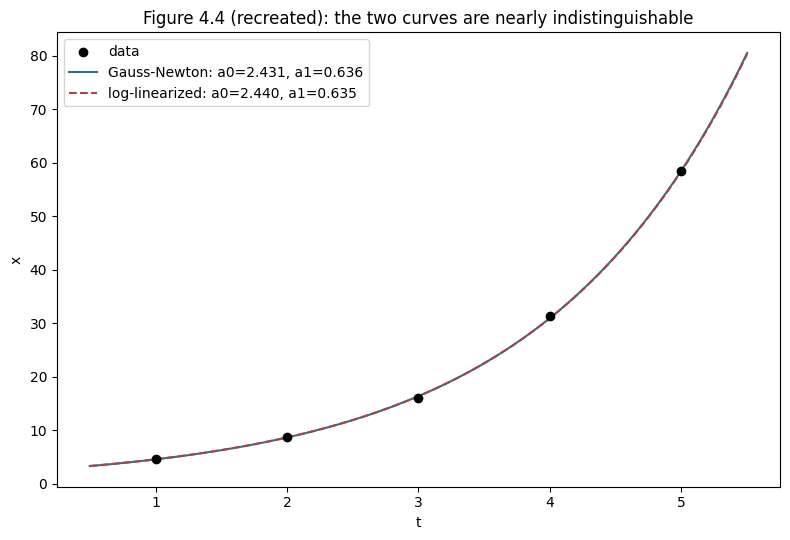

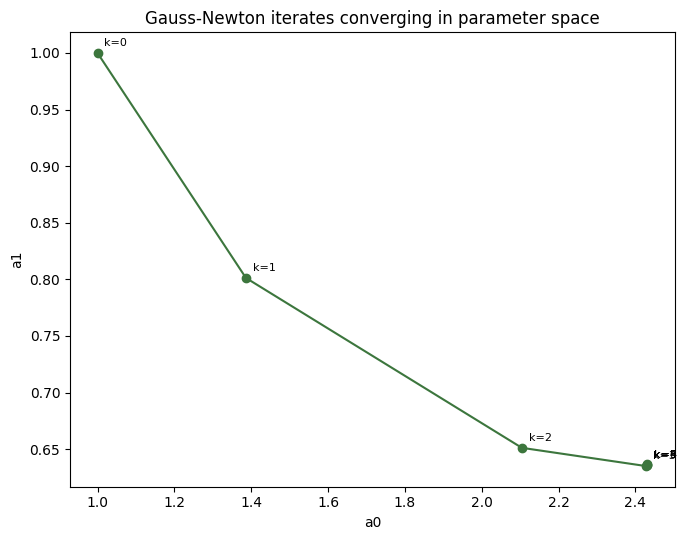

In [4]:
import matplotlib.pyplot as plt

t_curve = np.linspace(0.5, 5.5, 100)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(t_data, x_data, color="black", zorder=5, label="data")
ax.plot(t_curve, f_model(t_curve, *theta_final), color="#31708f", label=f"Gauss-Newton: a0={theta_final[0]:.3f}, a1={theta_final[1]:.3f}")
ax.plot(t_curve, f_model(t_curve, a0_log, a1_log), color="#a94442", linestyle="--", label=f"log-linearized: a0={a0_log:.3f}, a1={a1_log:.3f}")
ax.set_xlabel("t"); ax.set_ylabel("x")
ax.set_title("Figure 4.4 (recreated): the two curves are nearly indistinguishable")
ax.legend()
plt.tight_layout()
plt.savefig("gauss_newton_example4.png", dpi=130, bbox_inches="tight")
plt.show()

# Also visualize convergence: theta_history approaching the final answer
history_arr = np.array(history)
fig2, ax2 = plt.subplots(figsize=(7, 5.5))
ax2.plot(history_arr[:, 0], history_arr[:, 1], marker="o", color="#3c763d")
for k, (a0v, a1v) in enumerate(history_arr):
    ax2.annotate(f"k={k}", (a0v, a1v), textcoords="offset points", xytext=(5,5), fontsize=8)
ax2.set_xlabel("a0"); ax2.set_ylabel("a1")
ax2.set_title("Gauss-Newton iterates converging in parameter space")
plt.tight_layout()
plt.savefig("gauss_newton_convergence.png", dpi=130, bbox_inches="tight")
plt.show()


### 10. Verification, discussed (continued)

Both curves, plotted together, are visually almost indistinguishable — exactly matching the
book's own remark about Figure 4.4 — even though we've now shown numerically they're not
*exactly* the same fit (they optimize different objectives, differing at the third decimal place
in a way that's invisible on this plot but detectable via the SSE comparison above). The
convergence-path plot shows the iterates moving in decreasing steps toward the final answer,
essentially converged by iteration 3–4 — matching the book's own statement that 4 iterations were
enough for three-decimal-point accuracy.


---
## Summary

**One sentence:** Nonlinear least squares minimizes $SSE(\theta)=\sum_i[y_i-f(x_i,\theta)]^2$ via
the Gauss–Newton method — repeatedly linearizing $f$ around the current parameter estimate and
solving the resulting linear normal system for an update step — implemented here entirely from
scratch, exactly reproducing the book's Example 4 iteration-by-iteration and confirming it
converges to a genuinely different (and, in original-space SSE terms, better) answer than Sec.
4.1's log-linearization shortcut, despite the two curves being visually almost indistinguishable.

**One paragraph:** Any smooth minimum of $SSE(\theta)$ must be a critical point, giving the
generally-nonlinear system (4.8); Gauss–Newton solves this iteratively by Taylor-expanding $f$
to first order at each current estimate $\theta^{(k)}$, which converts the nonlinear system into
the linear normal equations $J^TJ\Delta\theta=J^T\Delta y$ (4.11) for the update step — verified
here to reduce exactly to Sec. 4.1's ordinary linear least squares (in a single step, with a
constant Jacobian) whenever $f$ is already linear in $\theta$. Implementing the method entirely
from scratch and applying it to Example 4 ($x=a_0e^{a_1t}$) reproduces the book's
iteration-by-iteration values essentially exactly, converging to $a_0\approx2.431,\ a_1\approx
0.636$ after about 4 iterations — independently confirmed by `scipy.optimize.curve_fit` — and
comparing the actual original-space SSE at both this answer and Sec. 4.1's log-linearized answer
($a_0\approx2.44,\ a_1\approx0.635$) confirms the Gauss–Newton solution achieves strictly lower
error on the objective this section actually cares about, even though the two fitted curves are
visually almost indistinguishable, exactly as the book's Figure 4.4 shows.

**Bullet points:**
- SSE minimization requires solving the generally-nonlinear critical-point system (4.7)-(4.8).
- Gauss–Newton linearizes $f$ (not $SSE$ directly) at each iteration, turning the problem into a sequence of linear solves (4.11) — reusing Sec. 4.1's machinery repeatedly.
- Verified symbolically and algebraically: Gauss–Newton reduces EXACTLY to ordinary linear least squares (in one step) when $f$ is linear in $\theta$.
- From-scratch implementation reproduces the book's Example 4 iterations exactly, cross-checked against `scipy.optimize.curve_fit`.
- Log-linearization (Sec. 4.1) and direct Gauss–Newton minimize genuinely DIFFERENT objectives (log-space vs. original-space SSE) — confirmed numerically that Gauss–Newton achieves lower original-space SSE, even though the resulting curves look nearly identical.

## Memory Aids

- **Mnemonic**: "Linearize the MODEL, not the ERROR" — Gauss–Newton's key trick in five words.
- **Mental model**: each Gauss–Newton step is "pretend it's flat right here, walk downhill on the
  flat approximation, repeat" — a sequence of locally-valid linear solves approximating a globally
  nonlinear minimization.
- **Common mistake**: assuming a linearizing transformation (like log) and direct nonlinear least
  squares must give the same answer — they generally don't, because they minimize error in
  different spaces (confirmed numerically here).
- **Common mistake**: forgetting that Gauss–Newton's Jacobian must be RE-evaluated at each new
  iterate (unless $f$ happens to be linear in $\theta$) — it is not a fixed matrix the way Sec.
  4.1's design matrix $A$ is.
- **Exam tip**: be able to state the four-step Gauss–Newton algorithm from memory (initial guess →
  solve normal system for the step → update → repeat until convergence), and know that it reduces
  to ordinary least squares as a special/limiting case, not a completely different method.

## Connections

- **← Section 4.1**: Gauss–Newton is proven here to be a strict generalization of that section's
  linear least squares — reducing to it exactly whenever $f$ is linear in $\theta$.
- **→ Section 4.3**: applying Gauss–Newton (or `scipy.optimize.curve_fit`) to actually fit epidemic
  model parameters (like $\beta,\gamma$) from data is exactly the subject of the next section.
- **→ Numerical optimization**: Gauss–Newton is the direct ancestor of the extremely widely used
  Levenberg–Marquardt algorithm (what `scipy.optimize.curve_fit` uses internally by default) —
  understanding Gauss–Newton is the foundation for understanding essentially all practical
  nonlinear curve-fitting software.
- **→ Machine learning**: the same "linearize locally, solve, repeat" strategy underlies many
  optimization algorithms in machine learning, though gradient descent (a simpler, more
  general-purpose relative) is more commonly taught first.
- **→ Statistics**: nonlinear regression (fitting models nonlinear in their parameters) is a
  standard topic in applied statistics, built entirely on this section's Gauss–Newton machinery.

*Practice problems for this section are in `../../chapter_04/exercises/section_4_2_exercises.md`, with full
worked solutions in `../../chapter_04/solutions/section_4_2_solutions.md`.*
